# Repaso General de Python

## Variables y tipos

In [1]:
# Variables y Tipos
distancia_parsec = 1.3  # float
nombre_estrella = "Proxima Centauri" # string

## Listas vs Tuplas

In [60]:
# Listas vs Tuplas
coordenadas_ra_dec = (14.49, -60.83) 
longitudes_onda = [400, 500, 600, 700] # nm

## Diccionarios

In [61]:
# Diccionarios
telescopio = {
    "nombre": "James Webb",
    "u_medida": "micras",
    "operativo": True
}

## Bucles y Condicionales

In [62]:
temperatura = -150.5  # Celsius

if temperatura < -200:
    print("Alerta: Temperatura extremadamente baja.")
elif temperatura > 0:
    print("Alerta: La muestra se está calentando.")
else:
    print("Estado: Estable.")

Estado: Estable.


In [63]:
# Lista de magnitudes detectadas por un fotómetro
magnitudes = [12.1, 11.5, 13.8, 12.0, 15.2]

print("Filtrando estrellas brillantes (Magnitud < 13):")
for m in magnitudes:
    if m < 13:
        print(f"Detección válida: {m}")

Filtrando estrellas brillantes (Magnitud < 13):
Detección válida: 12.1
Detección válida: 11.5
Detección válida: 12.0


In [64]:
energia = 100.0
pasos = 0

while energia > 10:
    energia -= 15.5  # Pierde energía en cada iteración
    pasos += 1
    print(f"Paso {pasos}: Energía restante = {energia:.2f}")

print("La simulación termina: Energía por debajo del umbral.")

Paso 1: Energía restante = 84.50
Paso 2: Energía restante = 69.00
Paso 3: Energía restante = 53.50
Paso 4: Energía restante = 38.00
Paso 5: Energía restante = 22.50
Paso 6: Energía restante = 7.00
La simulación termina: Energía por debajo del umbral.


## Funciones

In [65]:
# Definición de una función con parámetros
def energia_foton(longitud_onda_nm):
    """Calcula la energía de un fotón dada su longitud de onda."""
    h = 6.626e-34  # Constante de Planck
    c = 3e8         # Velocidad de la luz
    lam = longitud_onda_nm * 1e-9 # Convertir a metros
    
    energia = (h * c) / lam
    return energia

# Uso de la función
e = energia_foton(500)
print(f"La energía de un fotón de 500nm es: {e:.2e} Joules")

La energía de un fotón de 500nm es: 3.98e-19 Joules


##  List Comprehension

In [66]:
# Tenemos una lista de longitudes de onda
espectro_visible = [400, 500, 600, 700]

# Tarea: Calcular la energía para cada una usando la función anterior
# Forma tradicional:
energias_tradicional = []
for l in espectro_visible:
    energias_tradicional.append(energia_foton(l))

# Con List Comprehension:
energias_pro = [energia_foton(l) for l in espectro_visible]

# Incluso podemos añadir filtros (condicionales)
# Solo calcular energías para longitudes de onda menores a 650nm
energias_filtradas = [energia_foton(l) for l in espectro_visible if l < 650]

print(f"Energías calculadas: {energias_pro}")

Energías calculadas: [4.9695e-19, 3.9755999999999994e-19, 3.3129999999999997e-19, 2.839714285714285e-19]


# Librerías útiles

## Numpy

In [67]:
import numpy as np

# Creación de arreglos
tiempos = np.linspace(0, 10, 100) # De 0 a 10 con 100 puntos
datos_ruidosos = np.sin(tiempos) + np.random.normal(0, 0.1, 100)

# Operaciones vectorizadas (Rápido y eficiente)
rms = np.sqrt(np.mean(datos_ruidosos**2))

# Máscaras booleanas: Filtrar datos de forma profesional
datos_positivos = datos_ruidosos[datos_ruidosos > 0]

## Matplotlib

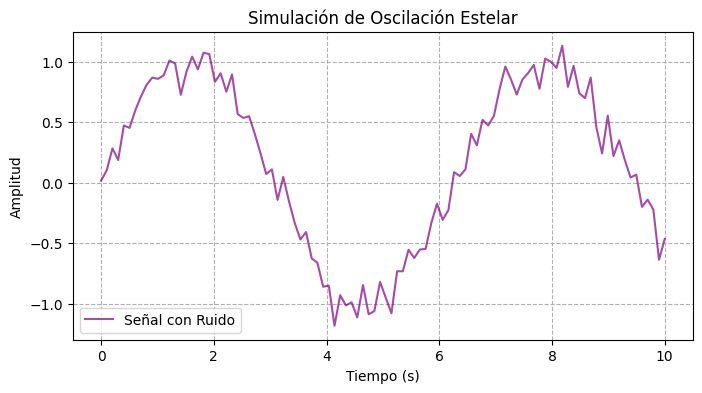

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tiempos, datos_ruidosos, label="Señal con Ruido", color='purple', alpha=0.7)
ax.set_title("Simulación de Oscilación")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Amplitud")
ax.grid(True, linestyle='--')
ax.legend()
plt.show()

## Pandas

In [69]:
import pandas as pd

# Crear un DataFrame de ejemplo (Simulando un catálogo de estrellas)
data = {
    'Estrella': ['Sirius', 'Canopus', 'Rigil Kentaurus'],
    'Magnitud': [-1.46, -0.74, -0.27],
    'Distancia_ly': [8.6, 310, 4.4]
}
df = pd.DataFrame(data)

# Análisis rápido
brillantes = df[df['Magnitud'] < -1]
distancia_media = df['Distancia_ly'].mean()

print(df.describe()) # Resumen estadístico instantáneo

       Magnitud  Distancia_ly
count  3.000000      3.000000
mean  -0.823333    107.666667
std    0.599361    175.238390
min   -1.460000      4.400000
25%   -1.100000      6.500000
50%   -0.740000      8.600000
75%   -0.505000    159.300000
max   -0.270000    310.000000


In [70]:
df

,Estrella,Magnitud,Distancia_ly
0,Sirius,-1.46,8.6
1,Canopus,-0.74,310.0
2,Rigil Kentaurus,-0.27,4.4


# Ejercicios

## Aproximación para $\ln(x)$

El logaritmo natural de $(1 + x)$ puede aproximarse mediante la serie de Maclaurin (serie de Taylor centrada en 0):

$$\ln(1 + x) = \sum_{n=1}^{\infty} \frac{(-1)^{n+1} \cdot x^n}{n} = x - \frac{x^2}{2} + \frac{x^3}{3} - \frac{x^4}{4} + \cdots
\quad \text{(Válido para $-1 < x \leq 1$)}
$$


- Implementar una función en Python que calcule esta aproximación para un valor $x$ y un número de términos $N$.
- Comparar el resultado con el valor real de $\ln(1 + x)$ usando las librerías math y numpy.

In [71]:
import math

def aprox_ln(x, N):
    """
    Aproxima ln(1 + x) usando la expansión en serie de Maclaurin.
    
    Args:
        x: Valor de entrada (debe estar en el rango -1 < x ≤ 1)
        N: Número de términos a usar en la aproximación.
    
    Returns:
        Aproximación de ln(1 + x) usando N términos.
    """
    if x <= -1 or x > 1:
        raise ValueError("x debe estar en el rango (-1, 1]")
    
    aproximacion = 0.0
    for n in range(1, N + 1):
        # Implementación directa de la fórmula del sumatorio
        termino = ((-1) ** (n + 1)) * (x ** n) / n
        aproximacion += termino
    
    return aproximacion

# --- Prueba del código ---
x = 0.5
n_terminos = 10

valor_real_math = math.log(1 + x)
valor_real_numpy = math.log(1 + x)
valor_aprox = aprox_ln(x, n_terminos)

error_absoluto_math = abs(valor_aprox - valor_real_math)
error_porcentual_math = (error_absoluto_math / abs(valor_real_math)) * 100 

error_absoluto_numpy = abs(valor_aprox - valor_real_numpy)
error_porcentual_numpy = (error_absoluto_numpy / abs(valor_real_numpy)) * 100 

print(f"Valor real ln(1 + {x}) con math = {valor_real_math:.10f}")
print(f"Valor real ln(1 + {x}) con numpy = {valor_real_numpy:.10f}")
print(f"Aprox. con N = {n_terminos}: {valor_aprox:.10f}")
print(f"Error math: {error_absoluto_math:.2e} ({error_porcentual_math:.4f}%)")
print(f"Error numpy: {error_absoluto_numpy:.2e} ({error_porcentual_numpy:.4f}%)")

Valor real ln(1 + 0.5) con math = 0.4054651081
Valor real ln(1 + 0.5) con numpy = 0.4054651081
Aprox. con N = 10: 0.4054346478
Error math: 3.05e-05 (0.0075%)
Error numpy: 3.05e-05 (0.0075%)


## Grafica de funciones en el plano $xy$
Graficar las funciones $y_1(x) = 3 + e^{-x} \sin(6x)$ y $y_2(x) = 4 + e^{-x} \cos(6x)$ para $0 \leq x \leq 5$ en un mismo sistema de ejes. La gráfica debe incluir:


- Etiquetas para los ejes
- Un título
- Una leyenda

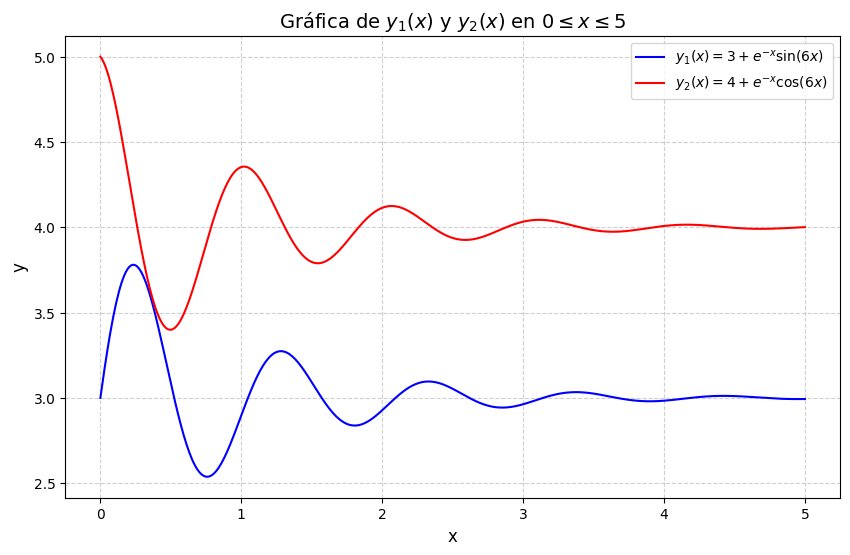

In [72]:
# Definir el rango de x
x = np.linspace(0, 5, 500)  # 500 puntos entre 0 y 5

# Definir las funciones y1(x) y y2(x)
y1 = 3 + np.exp(-x) * np.sin(6 * x)
y2 = 4 + np.exp(-x) * np.cos(6 * x)

# Crear la figura y los ejes
plt.figure(figsize=(10, 6))

# Graficar ambas funciones
plt.plot(x, y1, label=r'$y_1(x) = 3 + e^{-x} \sin(6x)$', color='blue')
plt.plot(x, y2, label=r'$y_2(x) = 4 + e^{-x} \cos(6x)$', color='red')

# Añadir etiquetas y título
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title(r'Gráfica de $y_1(x)$ y $y_2(x)$ en $0 \leq x \leq 5$', fontsize=14)

# Añadir una leyenda
plt.legend(fontsize=10)

# Mostrar la cuadrícula para mejor visualización
plt.grid(True, linestyle='--', alpha=0.6)

# Mostrar la gráfica
plt.show()

## Números de Catalan
Los números de Catalan $C_n$ son una secuencia de enteros 1, 1, 2, 5, 14, 42, 132... que juegan un papel importante en mecánica cuántica y en la teoría de sistemas desordenados. (Fueron fundamentales en la demostración de Eugene Wigner de la llamada ley del semicírculo). Estos números vienen dados por:

$$C_0 = 1, \quad C_{n+1} = \frac{4n + 2}{n + 2} \, C_n.$$

Escribir un programa que imprima en orden creciente todos los números de Catalan menores o iguales a mil millones.

In [73]:
def catalan_numbers_up_to_limit(limit):
    n = 0
    C = 1  # C_0 = 1
    print(f"C_{n} = {C}")
    
    while True:
        next_C = C * (4 * n + 2) // (n + 2)
        if next_C > limit:
            break
        n += 1
        C = next_C
        print(f"C_{n} = {C}")

# Llamar a la función con el límite de mil millones (1,000,000,000)
catalan_numbers_up_to_limit(1e9)

C_0 = 1
C_1 = 1
C_2 = 2
C_3 = 5
C_4 = 14
C_5 = 42
C_6 = 132
C_7 = 429
C_8 = 1430
C_9 = 4862
C_10 = 16796
C_11 = 58786
C_12 = 208012
C_13 = 742900
C_14 = 2674440
C_15 = 9694845
C_16 = 35357670
C_17 = 129644790
C_18 = 477638700
